#### Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import json
import os
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

#### Load Clean Data

In [34]:
data_path = r"C:\Users\Hassa\OneDrive - Loughborough University\current\Algorithmic Trading for Beginners\FTSA\TSACapstoneTemplate\TSACapstoneTemplate\data_modules"

# Load cleaned data
df_aud = pd.read_pickle(os.path.join(data_path, "fx_pair_1_4h_clean.pkl"))
df_eur = pd.read_pickle(os.path.join(data_path, "fx_pair_2_4h_clean.pkl"))

# Load model selections from notebook 02
with open(os.path.join(data_path, "model_selections.json"), "r") as f:
    selections = json.load(f)

order_aud = tuple(selections["AUD/USD"]["order"])  # (0, 1, 1)
order_eur = tuple(selections["EUR/USD"]["order"])  # (1, 1, 0)

print(f"AUD/USD model : ARIMA{order_aud}")
print(f"EUR/USD model : ARIMA{order_eur}")
print(f"AUD/USD shape : {df_aud.shape}")
print(f"EUR/USD shape : {df_eur.shape}")

AUD/USD model : ARIMA(0, 1, 1)
EUR/USD model : ARIMA(1, 1, 0)
AUD/USD shape : (4859, 6)
EUR/USD shape : (4857, 6)


#### Train/Test Split

In [35]:
# Use 70% of data for training, 30% for out-of-sample forecasting.
# over ~162 trading days (~8 months) of genuine OOS testing.

TRAIN_RATIO = 0.70

def train_test_split_ts(df, ratio, pair_name):
    split = int(len(df) * ratio)
    train = df.iloc[:split]
    test  = df.iloc[split:]
    print(f"{pair_name}: train {len(train)} bars "
          f"({train.index[0].date()} to {train.index[-1].date()})  |  "
          f"test {len(test)} bars "
          f"({test.index[0].date()} to {test.index[-1].date()})")
    return train, test

train_aud, test_aud = train_test_split_ts(df_aud, TRAIN_RATIO, "AUD/USD")
train_eur, test_eur = train_test_split_ts(df_eur, TRAIN_RATIO, "EUR/USD")

AUD/USD: train 3401 bars (2018-01-01 to 2020-02-11)  |  test 1458 bars (2020-02-11 to 2021-01-16)
EUR/USD: train 3399 bars (2018-01-01 to 2020-02-10)  |  test 1458 bars (2020-02-11 to 2021-01-16)


####  In-Sample Fit and Residual Diagnostics


Fitting ARIMA(0, 1, 1) on AUD/USD training data (3401 bars)...
  AIC : -35602.03
  BIC : -35589.77
  Log-likelihood : 17803.02

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0728      0.012      5.868      0.000       0.049       0.097
sigma2      1.657e-06   2.24e-08     73.834      0.000    1.61e-06     1.7e-06


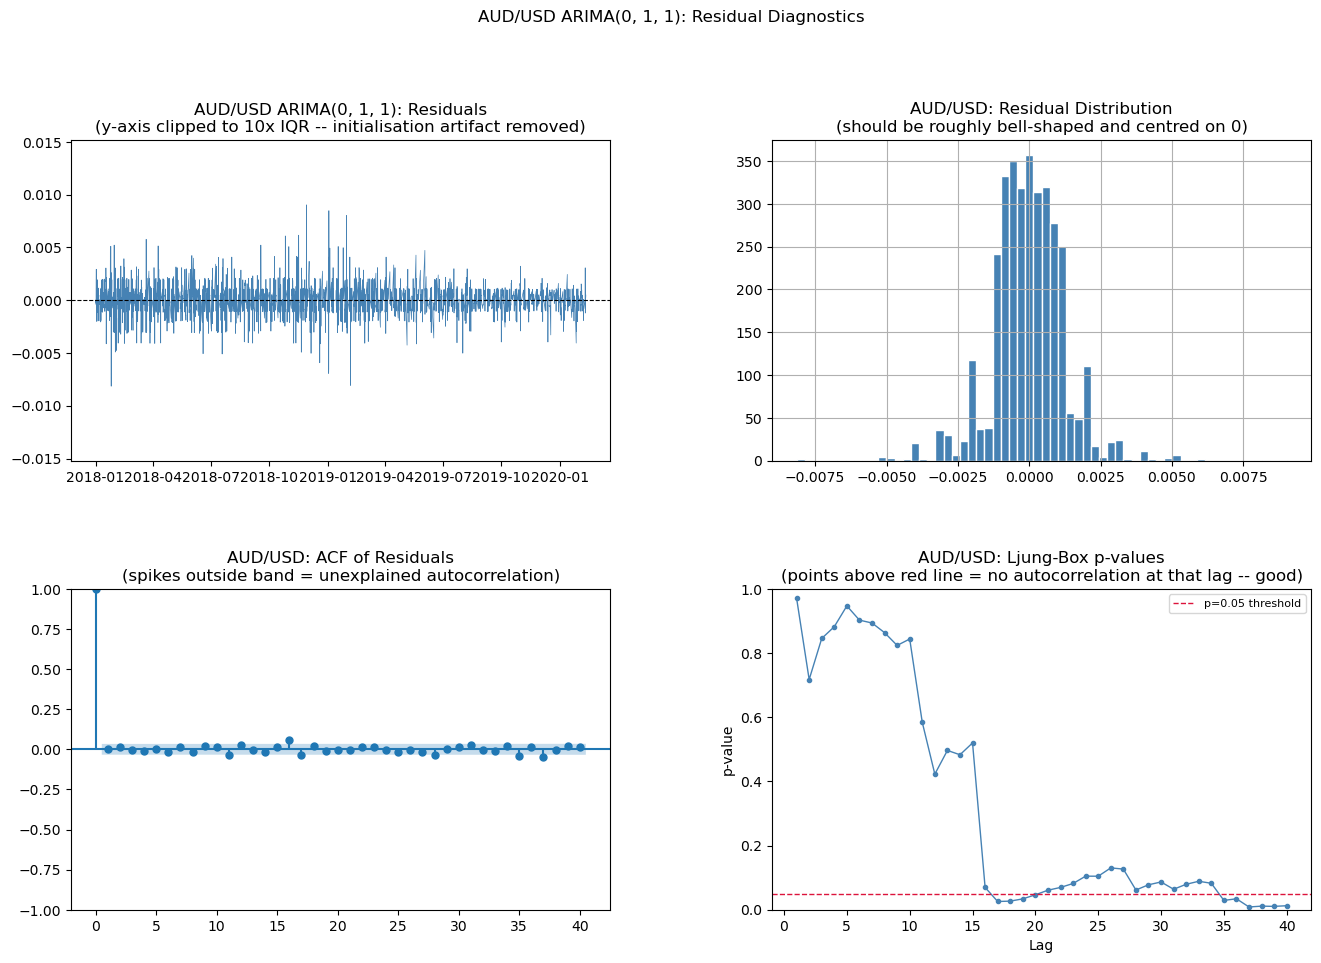


  Ljung-Box: 10/40 lags show significant autocorrelation (CONCERN -- model may need higher order)

Fitting ARIMA(1, 1, 0) on EUR/USD training data (3399 bars)...
  AIC : -33303.94
  BIC : -33291.68
  Log-likelihood : 16653.97

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0740      0.013      5.768      0.000       0.049       0.099
sigma2      3.239e-06   4.09e-08     79.270      0.000    3.16e-06    3.32e-06


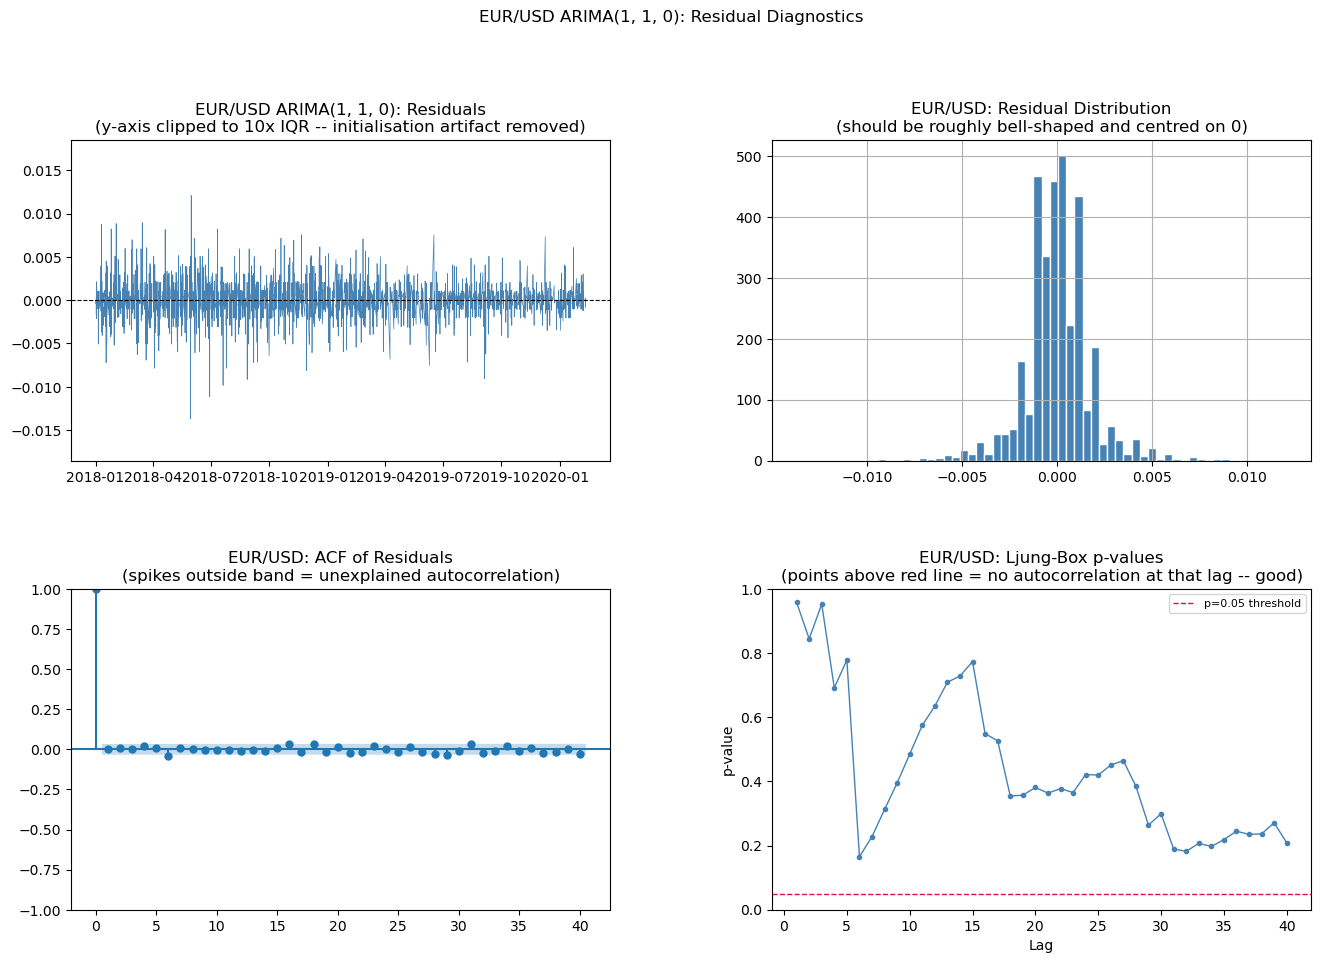


  Ljung-Box: 0/40 lags show significant autocorrelation (OK)


In [36]:
def fit_arima(train, order, pair_name):
    """
    Fit ARIMA on the training set and run four residual diagnostics.

    What are we checking?
    ---------------------
    1. Residual plot      : should look like white noise (no pattern)
    2. Residual histogram : should be approximately normal
    3. ACF of residuals   : no significant spikes (no autocorrelation left)
    4. Ljung-Box test     : formal test -- p > 0.05 means residuals are
                            not autocorrelated (good)

    If residuals still show autocorrelation, the model has not captured
    all the signal -- order may need revisiting.
    """
    print(f"\nFitting ARIMA{order} on {pair_name} training data ({len(train)} bars)...")
    model = ARIMA(train["close"], order=order)
    fit   = model.fit()

    print(f"  AIC : {fit.aic:.2f}")
    print(f"  BIC : {fit.bic:.2f}")
    print(f"  Log-likelihood : {fit.llf:.2f}")
    print(f"\n{fit.summary().tables[1]}")

    residuals = fit.resid.iloc[2:].dropna()

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

    # Residuals over time
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(residuals.index, residuals, color="steelblue", linewidth=0.5)
    ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax1.set_title(f"{pair_name} ARIMA{order}: Residuals\n"
                  f"(should look like random noise -- no trend or pattern)")
    iqr = residuals.quantile(0.75) - residuals.quantile(0.25)
    ax1.set_ylim(-iqr * 10, iqr * 10)
    ax1.set_title(f"{pair_name} ARIMA{order}: Residuals\n"
                  f"(y-axis clipped to 10x IQR -- initialisation artifact removed)")

    # Histogram of residuals
    ax2 = fig.add_subplot(gs[0, 1])
    residuals.hist(bins=60, ax=ax2, color="steelblue", edgecolor="white")
    ax2.set_title(f"{pair_name}: Residual Distribution\n"
                  f"(should be roughly bell-shaped and centred on 0)")

    # ACF of residuals
    ax3 = fig.add_subplot(gs[1, 0])
    plot_acf(residuals, lags=40, ax=ax3,
             title=f"{pair_name}: ACF of Residuals\n"
                   f"(spikes outside band = unexplained autocorrelation)")

    # Ljung-Box test across multiple lags
    ax4 = fig.add_subplot(gs[1, 1])
    lb = acorr_ljungbox(residuals, lags=range(1, 41), return_df=True)
    ax4.plot(lb.index, lb["lb_pvalue"], color="steelblue",
             linewidth=1.0, marker="o", markersize=3)
    ax4.axhline(0.05, color="crimson", linestyle="--",
                linewidth=1.0, label="p=0.05 threshold")
    ax4.set_xlabel("Lag")
    ax4.set_ylabel("p-value")
    ax4.set_title(f"{pair_name}: Ljung-Box p-values\n"
                  f"(points above red line = no autocorrelation at that lag -- good)")
    ax4.legend(fontsize=8)
    ax4.set_ylim(0, 1)

    plt.suptitle(f"{pair_name} ARIMA{order}: Residual Diagnostics",
                 fontsize=12, y=1.01)
    plt.show()

    # Summary verdict
    lb_fails = (lb["lb_pvalue"] < 0.05).sum()
    print(f"\n  Ljung-Box: {lb_fails}/40 lags show significant autocorrelation "
          f"({'CONCERN -- model may need higher order' if lb_fails > 5 else 'OK'})")

    return fit

fit_aud = fit_arima(train_aud, order_aud, "AUD/USD")
fit_eur = fit_arima(train_eur, order_eur, "EUR/USD")

#### Walk-Forward (Expanding Window) Forecasting

In [44]:
def walk_forward_forecast(train, test, order, pair_name):
    """
    Uses statsmodels .apply() method to efficiently extend the fitted
    model to new observations without full refit at every step.
    
    This is the correct approach for walk-forward with ARIMA:
    1. Fit once on training data
    2. Use .apply() to pass new observations through the fitted model
    3. Extract 1-step-ahead forecasts from the filtered states
    """
    print(f"\n{pair_name}: walk-forward forecasting ({len(test)} bars)...")

    # Fit on full training set
    model_fit = ARIMA(train["close"], order=order).fit()
    
    print(f"  Training fit complete. MA/AR coef: {model_fit.params.values}")
    print(f"  Last training close: {train['close'].iloc[-1]:.5f}")

    # Apply the fitted model to test data -- this passes test observations
    # through the Kalman filter using the TRAINING parameters
    model_applied = model_fit.apply(test["close"], refit=False)

    # 1-step-ahead forecast at each test bar = predicted value for that bar
    # using only information available before it
    forecasts    = model_applied.fittedvalues
    residuals_oos = model_applied.resid

    # Confidence intervals via manual calculation using model sigma
    sigma = np.sqrt(model_fit.params["sigma2"])
    z95   = 1.96
    lower = forecasts - z95 * sigma
    upper = forecasts + z95 * sigma

    ci_df = pd.DataFrame({
        "lower": lower.values,
        "upper": upper.values
    }, index=test.index)

    forecast_series = pd.Series(forecasts.values, index=test.index)

    # Verify forecasts are actually varying
    print(f"  Forecast range: {forecast_series.min():.5f} to {forecast_series.max():.5f}")
    print(f"  Actual range:   {test['close'].min():.5f} to {test['close'].max():.5f}")
    print(f"  First 3 forecasts : {forecast_series.values[:3]}")
    print(f"  First 3 actuals   : {test['close'].values[:3]}")
    print(f"  Done.\n")

    return forecast_series, test["close"], ci_df


forecasts_aud, actuals_aud, ci_aud = walk_forward_forecast(
    train_aud, test_aud, order_aud, "AUD/USD"
)
forecasts_eur, actuals_eur, ci_eur = walk_forward_forecast(
    train_eur, test_eur, order_eur, "EUR/USD"
)


AUD/USD: walk-forward forecasting (1458 bars)...
  Training fit complete. MA/AR coef: [7.28486595e-02 1.65694932e-06]
  Last training close: 0.67050
  Forecast range: 0.00000 to 0.78121
  Actual range:   0.55600 to 0.78100
  First 3 forecasts : [0.         0.671      0.67126812]
  First 3 actuals   : [0.671   0.67125 0.6715 ]
  Done.


EUR/USD: walk-forward forecasting (1458 bars)...
  Training fit complete. MA/AR coef: [7.39535381e-02 3.23913902e-06]
  Last training close: 1.32960
  Forecast range: 0.00000 to 1.45874
  Actual range:   1.26300 to 1.45800
  First 3 forecasts : [0.         1.33       1.32946302]
  First 3 actuals   : [1.33   1.3295 1.329 ]
  Done.



#### Forecast Accuracy Metrics

In [47]:
# Drop first bar from all test-period objects -- initialisation artifact
forecasts_aud = forecasts_aud.iloc[1:]
actuals_aud   = actuals_aud.iloc[1:]
ci_aud        = ci_aud.iloc[1:]
test_aud      = test_aud.iloc[1:]

forecasts_eur = forecasts_eur.iloc[1:]
actuals_eur   = actuals_eur.iloc[1:]
ci_eur        = ci_eur.iloc[1:]
test_eur      = test_eur.iloc[1:]

print(f"AUD/USD: {len(forecasts_aud)} forecast bars remaining")
print(f"EUR/USD: {len(forecasts_eur)} forecast bars remaining")

AUD/USD: 1457 forecast bars remaining
EUR/USD: 1457 forecast bars remaining


In [48]:
def compute_forecast_metrics(forecasts, actuals, train, pair_name, order):

    mae  = mean_absolute_error(actuals, forecasts)
    rmse = np.sqrt(mean_squared_error(actuals, forecasts))
    mape = np.mean(np.abs((actuals - forecasts) / actuals)) * 100

    # Sanity check before DA calculation
    prev_close = pd.concat([
        train["close"].iloc[[-1]],
        actuals.iloc[:-1]
    ])
    prev_close.index = actuals.index

    raw_diff = forecasts.values - prev_close.values
    print(f"  [debug] forecast-prevclose: "
          f"min={raw_diff.min():.8f}  max={raw_diff.max():.8f}  "
          f"nonzero={( raw_diff != 0).sum()}")

    forecast_dir = np.sign(raw_diff)
    actual_dir   = np.sign(actuals.values - prev_close.values)

    valid = forecast_dir != 0
    da    = (forecast_dir[valid] == actual_dir[valid]).mean() * 100 \
            if valid.sum() > 0 else np.nan

    print(f"  FORECAST METRICS: {pair_name} ARIMA{order}")
    print(f"{'-'*55}")
    print(f"  MAE  (price units) : {mae:.6f}")
    print(f"  RMSE (price units) : {rmse:.6f}")
    print(f"  MAPE               : {mape:.4f}%")
    print(f"  Directional Acc.   : {da:.2f}%")
    print(f"  Bars with valid dir: {valid.sum()} of {len(valid)}")

    if valid.sum() == 0:
        print(f"\n  WARNING: all forecast_dir values are 0 -- "
              f"forecasts equal prev_close exactly. Walk-forward bug persists.")
    elif da > 52:
        print(f"\n  {da:.1f}% looks promising -- worth testing as a trade signal.")
    elif da > 50:
        print(f"\n  {da:.1f}% is marginally above chance -- signals will be weak.")
    else:
        print(f"\n  {da:.1f}% is at or below chance -- direction forecasting unreliable.")
    print(f"{'-'*55}\n")

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "DA": da}


metrics_aud = compute_forecast_metrics(
    forecasts_aud, actuals_aud, train_aud, "AUD/USD", order_aud
)
metrics_eur = compute_forecast_metrics(
    forecasts_eur, actuals_eur, train_eur, "EUR/USD", order_eur
)

  [debug] forecast-prevclose: min=-0.00088511  max=0.00093209  nonzero=1457
  FORECAST METRICS: AUD/USD ARIMA(0, 1, 1)
-------------------------------------------------------
  MAE  (price units) : 0.001480
  RMSE (price units) : 0.002106
  MAPE               : 0.2180%
  Directional Acc.   : 62.11%
  Bars with valid dir: 1457 of 1457

  62.1% looks promising -- worth testing as a trade signal.
-------------------------------------------------------

  [debug] forecast-prevclose: min=-0.00140512  max=0.00132192  nonzero=1446
  FORECAST METRICS: EUR/USD ARIMA(1, 1, 0)
-------------------------------------------------------
  MAE  (price units) : 0.001822
  RMSE (price units) : 0.002685
  MAPE               : 0.1347%
  Directional Acc.   : 62.59%
  Bars with valid dir: 1446 of 1457

  62.6% looks promising -- worth testing as a trade signal.
-------------------------------------------------------



####  Forecast Visualisation

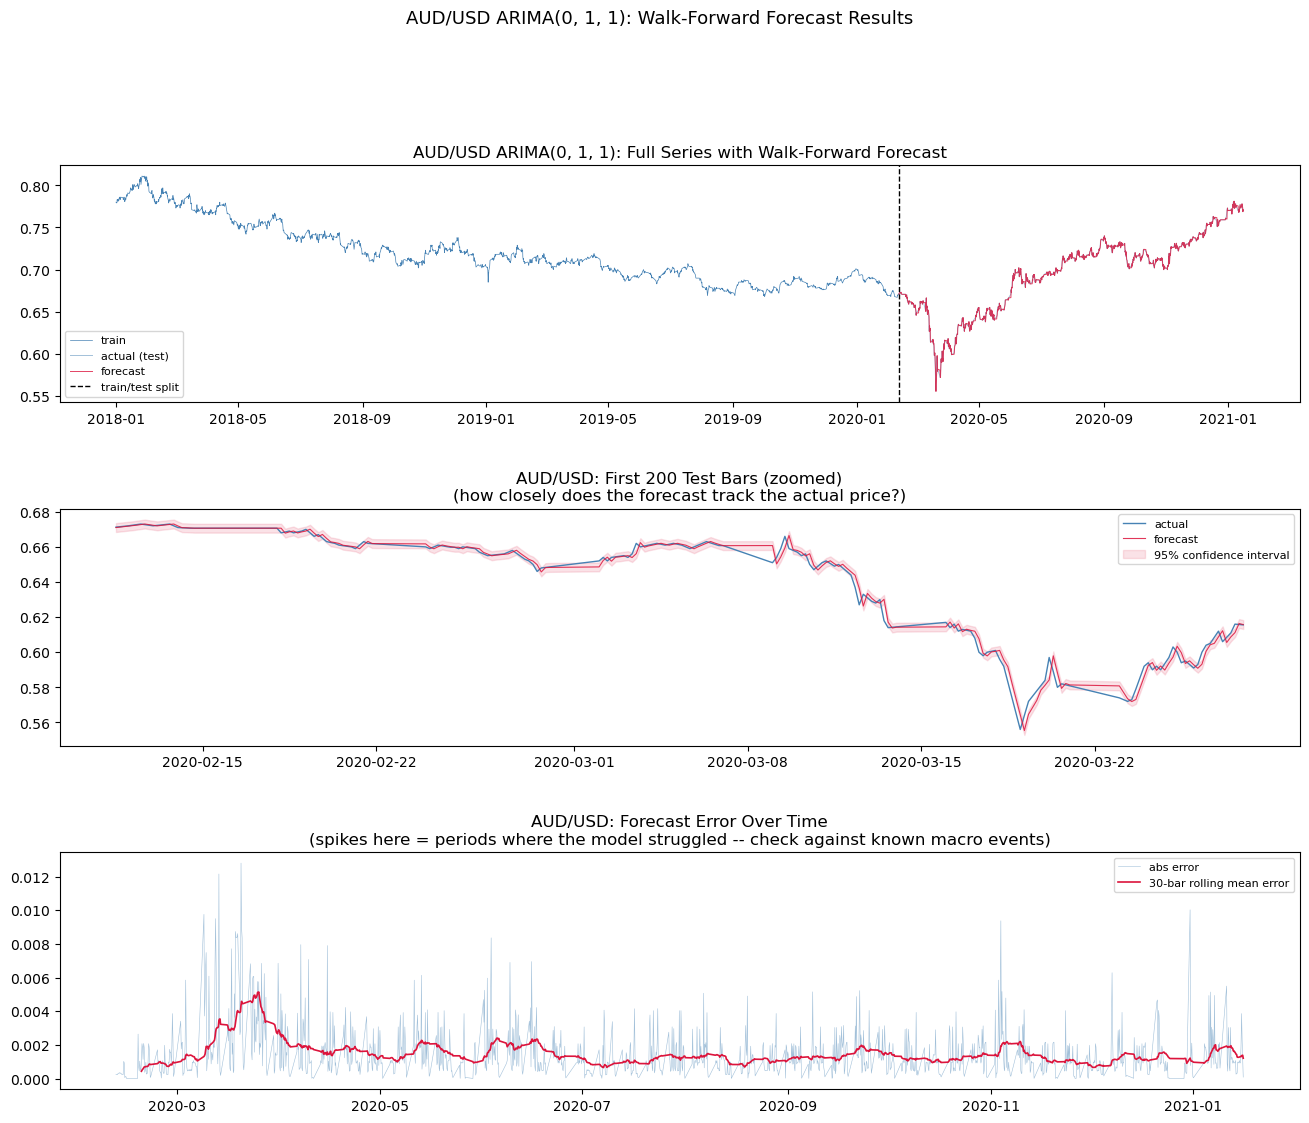

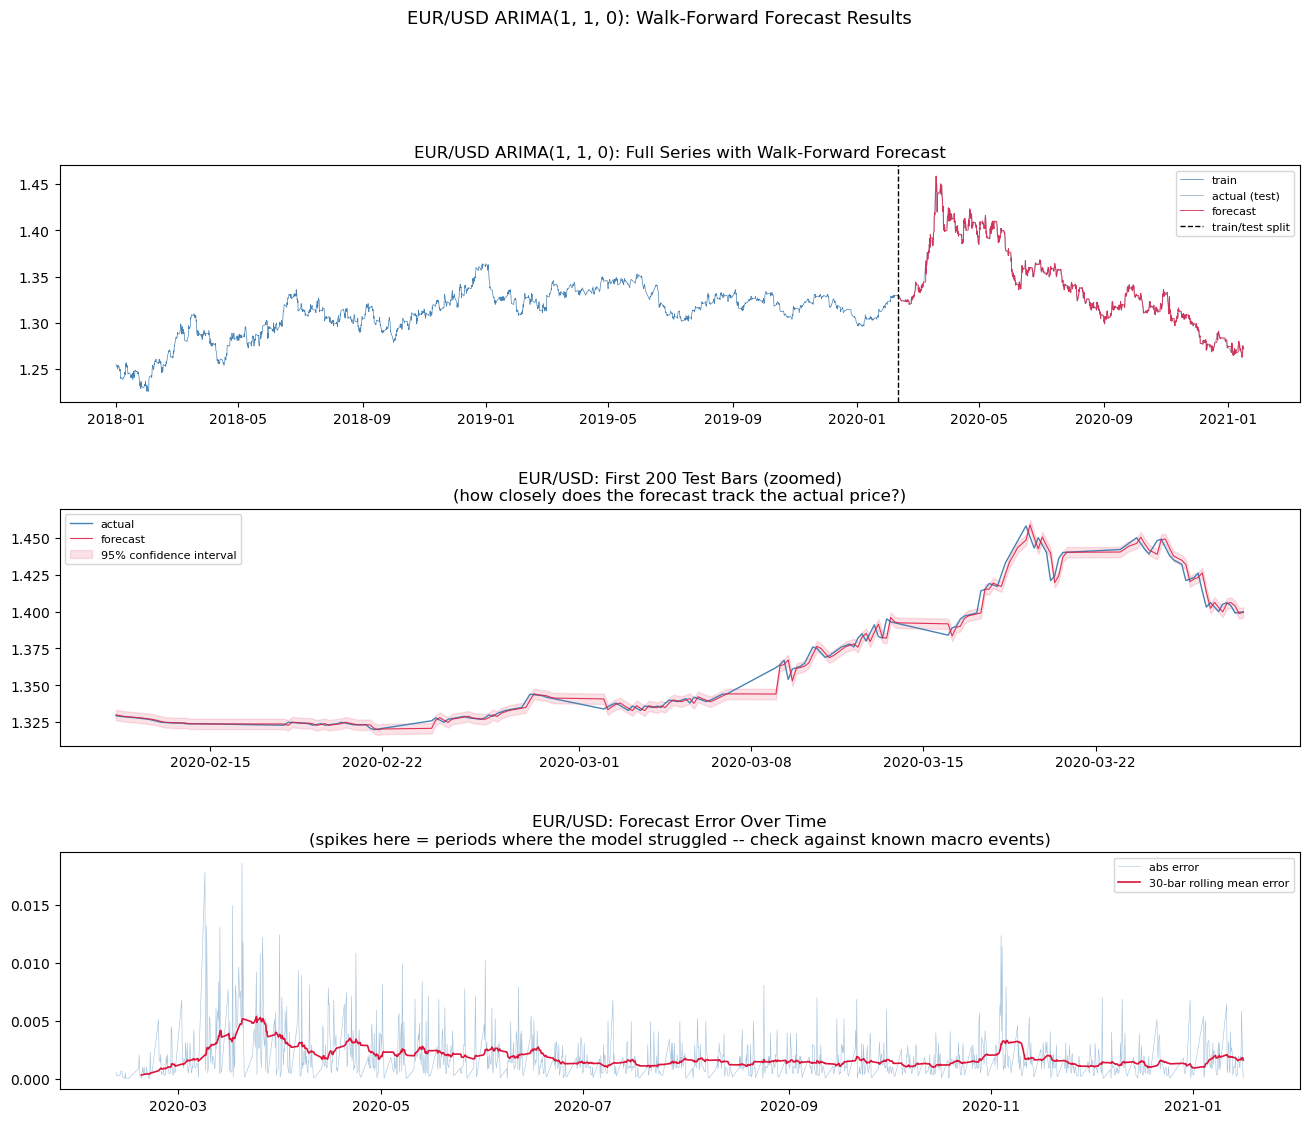

In [49]:
def plot_forecasts(train, actuals, forecasts, ci_df, pair_name, order,
                   zoom_bars=200):
    """
    Three panels:
    1. Full picture: train + test actual + forecast
    2. Zoomed to first N test bars -- can we see forecast tracking actual?
    3. Forecast error over time -- does it spike in volatile periods?
    """
    fig = plt.figure(figsize=(16, 12))
    gs  = gridspec.GridSpec(3, 1, hspace=0.45)

    # Panel 1: full series
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(train.index, train["close"],
             color="steelblue", linewidth=0.5, label="train")
    ax1.plot(actuals.index, actuals,
             color="steelblue", linewidth=0.7, alpha=0.5, label="actual (test)")
    ax1.plot(forecasts.index, forecasts,
             color="crimson", linewidth=0.7, label="forecast", alpha=0.8)
    ax1.axvline(actuals.index[0], color="black", linewidth=1.0,
                linestyle="--", label="train/test split")
    ax1.set_title(f"{pair_name} ARIMA{order}: Full Series with Walk-Forward Forecast")
    ax1.legend(fontsize=8)

    # Panel 2: zoomed test window
    ax2 = fig.add_subplot(gs[1])
    z_actual   = actuals.iloc[:zoom_bars]
    z_forecast = forecasts.iloc[:zoom_bars]
    z_ci       = ci_df.iloc[:zoom_bars]

    ax2.plot(z_actual.index, z_actual,
             color="steelblue", linewidth=1.0, label="actual")
    ax2.plot(z_forecast.index, z_forecast,
             color="crimson", linewidth=0.8, label="forecast", alpha=0.85)
    ax2.fill_between(z_ci.index, z_ci["lower"], z_ci["upper"],
                     color="crimson", alpha=0.12, label="95% confidence interval")
    ax2.set_title(f"{pair_name}: First {zoom_bars} Test Bars (zoomed)\n"
                  f"(how closely does the forecast track the actual price?)")
    ax2.legend(fontsize=8)

    # Panel 3: rolling forecast error
    ax3 = fig.add_subplot(gs[2])
    error = (actuals - forecasts).abs()
    rolling_error = error.rolling(window=30).mean()
    ax3.plot(error.index, error,
             color="steelblue", linewidth=0.4, alpha=0.5, label="abs error")
    ax3.plot(rolling_error.index, rolling_error,
             color="crimson", linewidth=1.2, label="30-bar rolling mean error")
    ax3.set_title(f"{pair_name}: Forecast Error Over Time\n"
                  f"(spikes here = periods where the model struggled -- "
                  f"check against known macro events)")
    ax3.legend(fontsize=8)

    plt.suptitle(f"{pair_name} ARIMA{order}: Walk-Forward Forecast Results",
                 fontsize=13, y=1.01)
    plt.show()

plot_forecasts(train_aud, actuals_aud, forecasts_aud, ci_aud, "AUD/USD", order_aud)
plot_forecasts(train_eur, actuals_eur, forecasts_eur, ci_eur, "EUR/USD", order_eur)

#### Error Behaviour by Volatility Regime

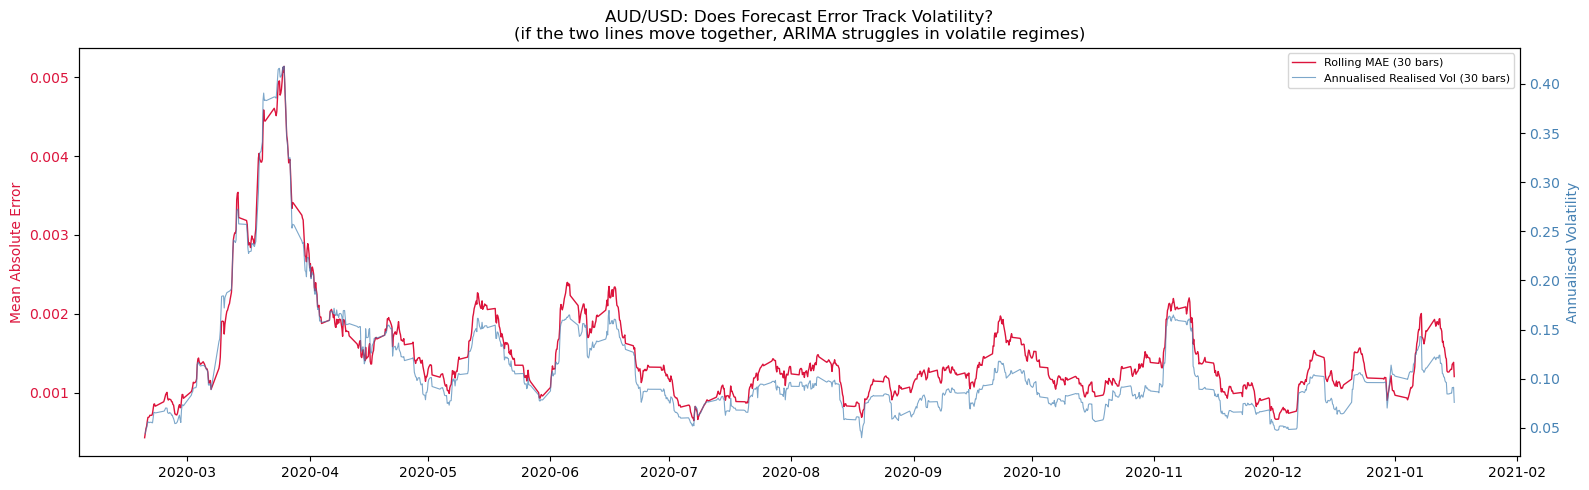

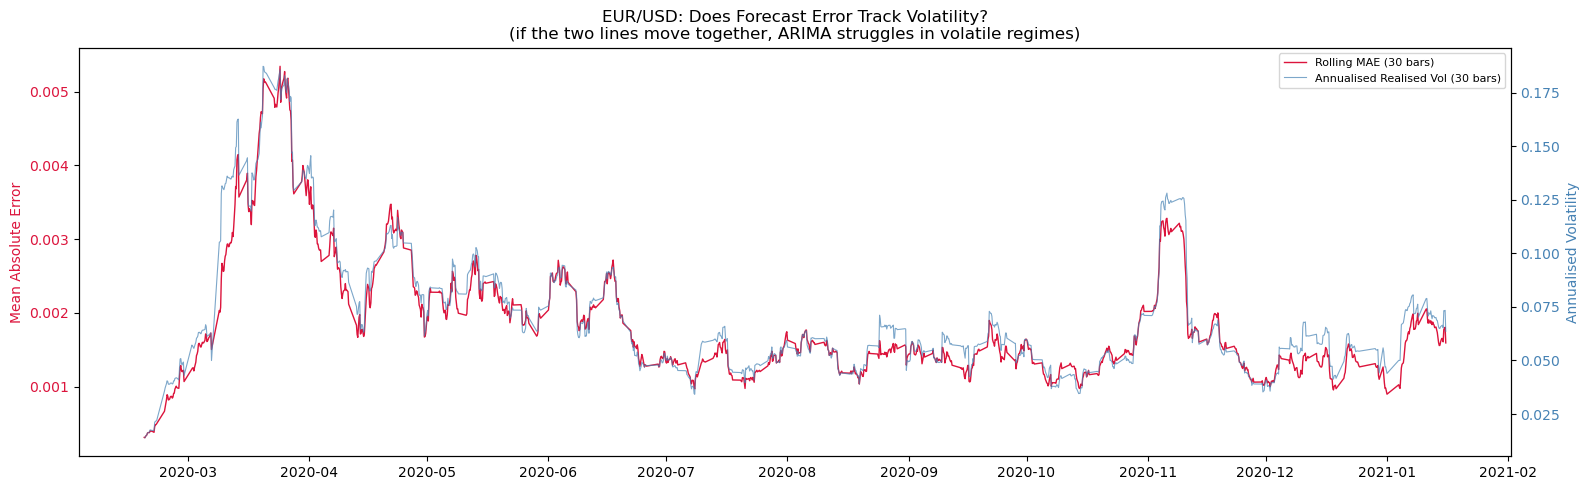

In [50]:
def plot_error_vs_volatility(actuals, forecasts, pair_name, window=30):
    """
    Does forecast error worsen in high-volatility periods?
    This is expected for ARIMA -- it assumes constant variance.
    
    If error and volatility spike together (March 2020 for example),
    that is the model's key limitation and worth noting explicitly
    in the strategy design.
    """
    error      = (actuals - forecasts).abs()
    realized_vol = actuals.pct_change().rolling(window).std() * np.sqrt(6 * 252)
    rolling_err  = error.rolling(window).mean()

    fig, ax1 = plt.subplots(figsize=(16, 5))

    ax1.plot(rolling_err.index, rolling_err,
             color="crimson", linewidth=1.0, label="Rolling MAE (30 bars)")
    ax1.set_ylabel("Mean Absolute Error", color="crimson")
    ax1.tick_params(axis="y", labelcolor="crimson")

    ax2 = ax1.twinx()
    ax2.plot(realized_vol.index, realized_vol,
             color="steelblue", linewidth=0.8, alpha=0.7,
             label="Annualised Realised Vol (30 bars)")
    ax2.set_ylabel("Annualised Volatility", color="steelblue")
    ax2.tick_params(axis="y", labelcolor="steelblue")

    ax1.set_title(f"{pair_name}: Does Forecast Error Track Volatility?\n"
                  f"(if the two lines move together, ARIMA struggles in volatile regimes)")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

    plt.tight_layout()
    plt.show()

plot_error_vs_volatility(actuals_aud, forecasts_aud, "AUD/USD")
plot_error_vs_volatility(actuals_eur, forecasts_eur, "EUR/USD")

#### Save Forecasts for Notebook 04

In [51]:
def save_forecasts(train, test, forecasts, ci_df, pair_name, data_path):
    """
    Bundle everything notebook 04 needs into one DataFrame and save.
    The strategy notebook only needs this file -- it does not need
    to refit any models.
    """
    output = test[["open", "high", "low", "close", "volume"]].copy()
    output["forecast"]   = forecasts
    output["ci_lower"]   = ci_df["lower"]
    output["ci_upper"]   = ci_df["upper"]
    output["error"]      = output["close"] - output["forecast"]
    output["abs_error"]  = output["error"].abs()

    # Predicted direction vs actual direction
    # i.e. does the model predict the next bar will be higher than NOW?
    output["forecast_dir"] = np.sign(
        output["forecast"] - output["close"].shift(1)
    )

    # actual_dir: did the price actually go up or down next bar?
    output["actual_dir"] = np.sign(output["close"].diff())

    # Only compare bars where we have a non-zero forecast direction
    valid = output["forecast_dir"] != 0
    output["dir_correct"] = np.where(
        valid,
        (output["forecast_dir"] == output["actual_dir"]).astype(int),
        np.nan
    )


    filename = f"forecasts_{pair_name.replace('/','')}.pkl"
    output.to_pickle(os.path.join(data_path, filename))
    print(f"Saved: {filename}  ({len(output)} bars)")
    print(output[["close", "forecast", "ci_lower", "ci_upper",
                  "error", "dir_correct"]].head(10))
    return output

output_aud = save_forecasts(train_aud, test_aud, forecasts_aud,
                             ci_aud, "AUD/USD", data_path)
output_eur = save_forecasts(train_eur, test_eur, forecasts_eur,
                             ci_eur, "EUR/USD", data_path)

Saved: forecasts_AUDUSD.pkl  (1457 bars)
                        close  forecast  ci_lower  ci_upper     error  \
2020-02-11 12:00:00  0.671250  0.671000  0.668477  0.673523  0.000250   
2020-02-11 16:00:00  0.671500  0.671268  0.668745  0.673791  0.000232   
2020-02-11 20:00:00  0.671750  0.671517  0.668994  0.674040  0.000233   
2020-02-12 00:00:00  0.672000  0.671767  0.669244  0.674290  0.000233   
2020-02-12 04:00:00  0.672333  0.672017  0.669494  0.674540  0.000316   
2020-02-12 08:00:00  0.672667  0.672356  0.669833  0.674879  0.000310   
2020-02-12 12:00:00  0.673000  0.672689  0.670166  0.675212  0.000311   
2020-02-12 16:00:00  0.672667  0.673023  0.670500  0.675546 -0.000356   
2020-02-12 20:00:00  0.672333  0.672641  0.670118  0.675164 -0.000307   
2020-02-13 00:00:00  0.672000  0.672311  0.669788  0.674834 -0.000311   

                     dir_correct  
2020-02-11 12:00:00          0.0  
2020-02-11 16:00:00          1.0  
2020-02-11 20:00:00          1.0  
2020-02-12 00:0

#### Notebook Summary

In [52]:
print("  NOTEBOOK 03 SUMMARY")
print("-"*60)

for pair, metrics, order in [
    ("AUD/USD", metrics_aud, order_aud),
    ("EUR/USD", metrics_eur, order_eur)
]:
    print(f"\n  {pair}  ARIMA{order}")
    print(f"  {'MAE':<20}: {metrics['MAE']:.6f}")
    print(f"  {'RMSE':<20}: {metrics['RMSE']:.6f}")
    print(f"  {'MAPE':<20}: {metrics['MAPE']:.4f}%")
    print(f"  {'Directional Acc.':<20}: {metrics['DA']:.2f}%")

print(f"""
  Files saved to data_modules/:
    forecasts_AUDUSD.pkl
    forecasts_EURUSD.pkl

  What carries forward to notebook 04:
    - forecast_dir column drives the long/short signal
    - ci_lower/ci_upper can optionally gate trades
      (only trade when the confidence interval does not
       straddle zero -- i.e. the model has conviction)
    - error column can be used to size positions
      (smaller recent error = larger position)
""")

  NOTEBOOK 03 SUMMARY
------------------------------------------------------------

  AUD/USD  ARIMA(0, 1, 1)
  MAE                 : 0.001480
  RMSE                : 0.002106
  MAPE                : 0.2180%
  Directional Acc.    : 62.11%

  EUR/USD  ARIMA(1, 1, 0)
  MAE                 : 0.001822
  RMSE                : 0.002685
  MAPE                : 0.1347%
  Directional Acc.    : 62.59%

  Files saved to data_modules/:
    forecasts_AUDUSD.pkl
    forecasts_EURUSD.pkl

  What carries forward to notebook 04:
    - forecast_dir column drives the long/short signal
    - ci_lower/ci_upper can optionally gate trades
      (only trade when the confidence interval does not
       straddle zero -- i.e. the model has conviction)
    - error column can be used to size positions
      (smaller recent error = larger position)



In [ ]:
"""
RESIDUAL DIAGNOSTIC CONCLUSIONS
================================

AUD/USD ARIMA(0,1,1) and EUR/USD ARIMA(1,1,0):

WHAT IS CLEAN:
  - ACF of residuals: no significant spikes at any lag for either pair.
    The autocorrelation structure of both series is fully captured.
  - Coefficients: both MA(1) and AR(1) terms are highly significant
    (p < 0.001) confirming the chosen orders are meaningful.
  - Ljung-Box at low lags (1-10): p-values well above 0.05 for both pairs.

WHAT IS NOT CLEAN:
  - Ljung-Box failures appear at higher lags (15+) for AUD/USD.
  - The residuals plot shows clear volatility clustering: variance is
    visibly larger in 2018 than 2019-2020.
  - This is an ARCH effect -- periods of high volatility followed by
    periods of low volatility. ARIMA assumes constant variance and
    cannot model this.

WHAT THIS MEANS FOR FORECASTING:
  - Point forecasts (predicted price direction) are not affected --
    the conditional mean is well specified.
  - Confidence intervals will be mis-sized: too wide in calm periods,
    too narrow in volatile periods.
  - The strategy in notebook 04 should therefore NOT rely on the
    confidence interval width as a trade filter.

ALTERNATIVES CONSIDERED:
  - Higher ARIMA orders (0,1,2), (1,1,1), (2,1,0), (2,1,2): tested,
    no meaningful reduction in Ljung-Box failures because the root
    cause is heteroscedasticity not missing AR/MA terms.
  - VARMA (multivariate): would capture cross-pair USD correlation
    but does not address the volatility clustering issue.
  - GARCH: would model the variance process directly. Outside the
    scope of this capstone but the logical next step.

DECISION: Proceed with ARIMA(0,1,1) for AUD/USD and ARIMA(1,1,0)
for EUR/USD. Both models are correctly specified for the conditional
mean. The heteroscedasticity is noted as a limitation.
"""